### Objectives

By the end of this notebook, we will:

- Understand the target variable distribution.
- Analyze numerical feature distributions.
- Analyze categorical feature distributions.
- Detect outliers.
- Study feature correlations.
- Discover relationships between features and battery failure.
- Generate insights that explain the dataset.

step 1: import the required libraries 


In [69]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

step 2: load the clean dataset 

In [70]:
df = pd.read_csv(r"D:/machine learning/machine_learning/decsion_tree_project/ev__battery_life/dataset/processed_data/cleaned_ev_battery_dataset.csv")
df

,manufacturing_year,battery_capacity_kwh,odometer_km,vehicle_age_years,cycle_count,battery_health_percent,state_of_charge,depth_of_discharge,state_of_health,cell_voltage_avg,cell_voltage_std,pack_voltage,cell_temperature_avg,cell_temperature_max,internal_resistance,charge_efficiency,discharge_efficiency,remaining_capacity,capacity_loss_percent,charging_cycles_last_month,fast_charge_ratio,slow_charge_ratio,average_charge_power_kw,average_charging_time,overnight_charging_ratio,home_charging_ratio,charging_interruptions,overcharge_events,average_speed,average_trip_distance,aggressive_acceleration_score,hard_braking_score,regenerative_braking_usage,highway_driving_ratio,city_driving_ratio,daily_distance,average_ambient_temperature,maximum_temperature,minimum_temperature,humidity,altitude,dust_exposure,last_service_days,cooling_system_health,firmware_updates,previous_faults,maintenance_score,thermal_runaway_risk,voltage_imbalance,temperature_variance,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,vehicle_brand_BMW,vehicle_brand_BYD,vehicle_brand_Ford,vehicle_brand_GM,vehicle_brand_Honda,vehicle_brand_Hyundai,vehicle_brand_Kia,vehicle_brand_Lucid,vehicle_brand_MG,vehicle_brand_Mahindra,vehicle_brand_Mercedes,vehicle_brand_Nissan,vehicle_brand_Renault,vehicle_brand_Rivian,vehicle_brand_Tata,vehicle_brand_Tesla,vehicle_brand_Toyota,vehicle_brand_Volkswagen,vehicle_brand_Volvo,vehicle_model_Ariya,vehicle_model_Atto 3,vehicle_model_BE 6,vehicle_model_Cadillac Lyriq,vehicle_model_Chevrolet Bolt,vehicle_model_Comet EV,vehicle_model_Dolphin,vehicle_model_EQB,vehicle_model_EQE,vehicle_model_EQS,vehicle_model_EV6,vehicle_model_EV9,vehicle_model_EX30,vehicle_model_EX90,vehicle_model_F-150 Lightning,vehicle_model_Gravity,vehicle_model_Han,vehicle_model_ID.3,vehicle_model_ID.4,vehicle_model_ID.Buzz,vehicle_model_Ioniq 5,vehicle_model_Ioniq 6,vehicle_model_Kona Electric,vehicle_model_Leaf,vehicle_model_MG4,vehicle_model_Megane E-Tech,vehicle_model_Model 3,vehicle_model_Model S,vehicle_model_Model X,vehicle_model_Model Y,vehicle_model_Mustang Mach-E,vehicle_model_Nexon EV,vehicle_model_Niro EV,vehicle_model_Prologue,vehicle_model_Punch EV,vehicle_model_Q4 e-tron,vehicle_model_R1S,vehicle_model_R1T,vehicle_model_Silverado EV,vehicle_model_Song Plus,vehicle_model_Tang,vehicle_model_Tiago EV,vehicle_model_XC40 Recharge,vehicle_model_XUV400,vehicle_model_ZS EV,vehicle_model_Zoe,vehicle_model_bZ3,vehicle_model_bZ4X,vehicle_model_e-tron,vehicle_model_e-tron GT,vehicle_model_e:Ny1,vehicle_model_i4,vehicle_model_i7,vehicle_model_iX,vehicle_type_Hatchback,vehicle_type_SUV,vehicle_type_Sedan,vehicle_type_Truck,vehicle_type_Van,battery_manufacturer_CATL,battery_manufacturer_Envision AESC,battery_manufacturer_Guoxuan,battery_manufacturer_LG Energy Solution,battery_manufacturer_Northvolt,battery_manufacturer_Panasonic,battery_manufacturer_SK On,battery_manufacturer_Samsung SDI,battery_chemistry_LMO,battery_chemistry_LTO,battery_chemistry_NCA,battery_chemistry_NMC,drive_type_FWD,drive_type_RWD,fleet_or_private_Private,terrain_type_Desert,terrain_type_Flat,terrain_type_Hilly,terrain_type_Mountainous,battery_failure
0,2019.0,82.54,98163.0,6.94,250.0,73.61,85.23,26.34,72.93,3.3558,0.01829,934.42,-15.66,-10.04,0.6585,94.63,80.08,60.76,26.39,4.0,0.206,0.797,25.46,212.2,0.543,0.675,0.0,2.0,58.0,38.7,0.0,7.0,69.4,0.352,0.676,50.6,-14.3,-5.9,-21.5,100.0,400.2,20.4,159.0,79.3,2.0,0.0,94.8,48.7,15.30,5.28,2.0,3.0,0.0,0.0,53.5,66.0,65.2,0.0,401.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0


step 3: display the dataset 

In [71]:
df.head()

,manufacturing_year,battery_capacity_kwh,odometer_km,vehicle_age_years,cycle_count,battery_health_percent,state_of_charge,depth_of_discharge,state_of_health,cell_voltage_avg,cell_voltage_std,pack_voltage,cell_temperature_avg,cell_temperature_max,internal_resistance,charge_efficiency,discharge_efficiency,remaining_capacity,capacity_loss_percent,charging_cycles_last_month,fast_charge_ratio,slow_charge_ratio,average_charge_power_kw,average_charging_time,overnight_charging_ratio,home_charging_ratio,charging_interruptions,overcharge_events,average_speed,average_trip_distance,aggressive_acceleration_score,hard_braking_score,regenerative_braking_usage,highway_driving_ratio,city_driving_ratio,daily_distance,average_ambient_temperature,maximum_temperature,minimum_temperature,humidity,altitude,dust_exposure,last_service_days,cooling_system_health,firmware_updates,previous_faults,maintenance_score,thermal_runaway_risk,voltage_imbalance,temperature_variance,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,vehicle_brand_BMW,vehicle_brand_BYD,vehicle_brand_Ford,vehicle_brand_GM,vehicle_brand_Honda,vehicle_brand_Hyundai,vehicle_brand_Kia,vehicle_brand_Lucid,vehicle_brand_MG,vehicle_brand_Mahindra,vehicle_brand_Mercedes,vehicle_brand_Nissan,vehicle_brand_Renault,vehicle_brand_Rivian,vehicle_brand_Tata,vehicle_brand_Tesla,vehicle_brand_Toyota,vehicle_brand_Volkswagen,vehicle_brand_Volvo,vehicle_model_Ariya,vehicle_model_Atto 3,vehicle_model_BE 6,vehicle_model_Cadillac Lyriq,vehicle_model_Chevrolet Bolt,vehicle_model_Comet EV,vehicle_model_Dolphin,vehicle_model_EQB,vehicle_model_EQE,vehicle_model_EQS,vehicle_model_EV6,vehicle_model_EV9,vehicle_model_EX30,vehicle_model_EX90,vehicle_model_F-150 Lightning,vehicle_model_Gravity,vehicle_model_Han,vehicle_model_ID.3,vehicle_model_ID.4,vehicle_model_ID.Buzz,vehicle_model_Ioniq 5,vehicle_model_Ioniq 6,vehicle_model_Kona Electric,vehicle_model_Leaf,vehicle_model_MG4,vehicle_model_Megane E-Tech,vehicle_model_Model 3,vehicle_model_Model S,vehicle_model_Model X,vehicle_model_Model Y,vehicle_model_Mustang Mach-E,vehicle_model_Nexon EV,vehicle_model_Niro EV,vehicle_model_Prologue,vehicle_model_Punch EV,vehicle_model_Q4 e-tron,vehicle_model_R1S,vehicle_model_R1T,vehicle_model_Silverado EV,vehicle_model_Song Plus,vehicle_model_Tang,vehicle_model_Tiago EV,vehicle_model_XC40 Recharge,vehicle_model_XUV400,vehicle_model_ZS EV,vehicle_model_Zoe,vehicle_model_bZ3,vehicle_model_bZ4X,vehicle_model_e-tron,vehicle_model_e-tron GT,vehicle_model_e:Ny1,vehicle_model_i4,vehicle_model_i7,vehicle_model_iX,vehicle_type_Hatchback,vehicle_type_SUV,vehicle_type_Sedan,vehicle_type_Truck,vehicle_type_Van,battery_manufacturer_CATL,battery_manufacturer_Envision AESC,battery_manufacturer_Guoxuan,battery_manufacturer_LG Energy Solution,battery_manufacturer_Northvolt,battery_manufacturer_Panasonic,battery_manufacturer_SK On,battery_manufacturer_Samsung SDI,battery_chemistry_LMO,battery_chemistry_LTO,battery_chemistry_NCA,battery_chemistry_NMC,drive_type_FWD,drive_type_RWD,fleet_or_private_Private,terrain_type_Desert,terrain_type_Flat,terrain_type_Hilly,terrain_type_Mountainous,battery_failure
0,2019.0,82.54,98163.0,6.94,250.0,73.61,85.23,26.34,72.93,3.3558,0.01829,934.42,-15.66,-10.04,0.6585,94.63,80.08,60.76,26.39,4.0,0.206,0.797,25.46,212.2,0.543,0.675,0.0,2.0,58.0,38.7,0.0,7.0,69.4,0.352,0.676,50.6,-14.3,-5.9,-21.5,100.0,400.2,20.4,159.0,79.3,2.0,0.0,94.8,48.7,15.30,5.28,2.0,3.0,0.0,0.0,53.5,66.0,65.2,0.0,401.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0


In [72]:
df.shape

(200000, 157)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 157 entries, manufacturing_year to battery_failure
dtypes: float64(156), int64(1)
memory usage: 239.6 MB


step 4: target variable distribution 

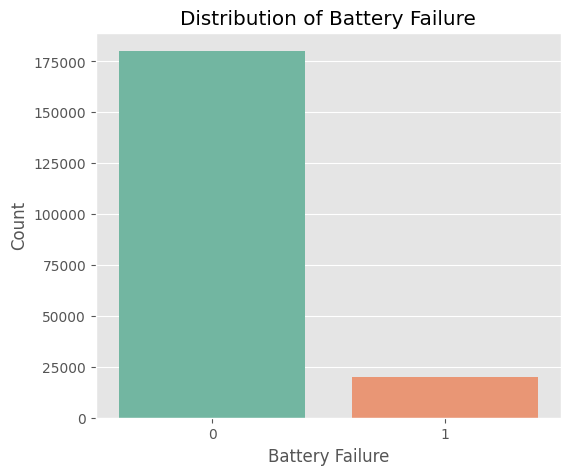

In [74]:
plt.figure(figsize=(6, 5))
sns.countplot(
    x="battery_failure", 
    data=df,
    palette = "Set2"
)
plt.title("Distribution of Battery Failure")
plt.xlabel("Battery Failure")
plt.ylabel("Count")
plt.show()

percentage distribution 

In [75]:
(df["battery_failure"].value_counts(normalize=True)* 100).round(2)

battery_failure
0    90.04
1     9.96
Name: proportion, dtype: float64

Step 5 — Numerical Features Summary

In [76]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
manufacturing_year,200000.0,2019.525840,2.804071,2015.00,2017.00,2020.00,2022.00,2024.00
battery_capacity_kwh,200000.0,76.205810,20.932100,25.00,61.56,75.35,89.48,149.01
odometer_km,200000.0,101786.467960,86176.455206,500.00,37850.00,78919.00,141873.25,450000.00
vehicle_age_years,200000.0,6.489281,2.822514,1.37,4.04,6.34,8.96,11.55
cycle_count,200000.0,293.384965,277.562841,1.00,100.00,218.00,402.00,3369.00
...,...,...,...,...,...,...,...,...
terrain_type_Desert,200000.0,0.144815,0.351915,0.00,0.00,0.00,0.00,1.00
terrain_type_Flat,200000.0,0.373075,0.483623,0.00,0.00,0.00,1.00,1.00
terrain_type_Hilly,200000.0,0.192460,0.394233,0.00,0.00,0.00,0.00,1.00
terrain_type_Mountainous,200000.0,0.096325,0.295037,0.00,0.00,0.00,0.00,1.00


Step 6 — Histograms

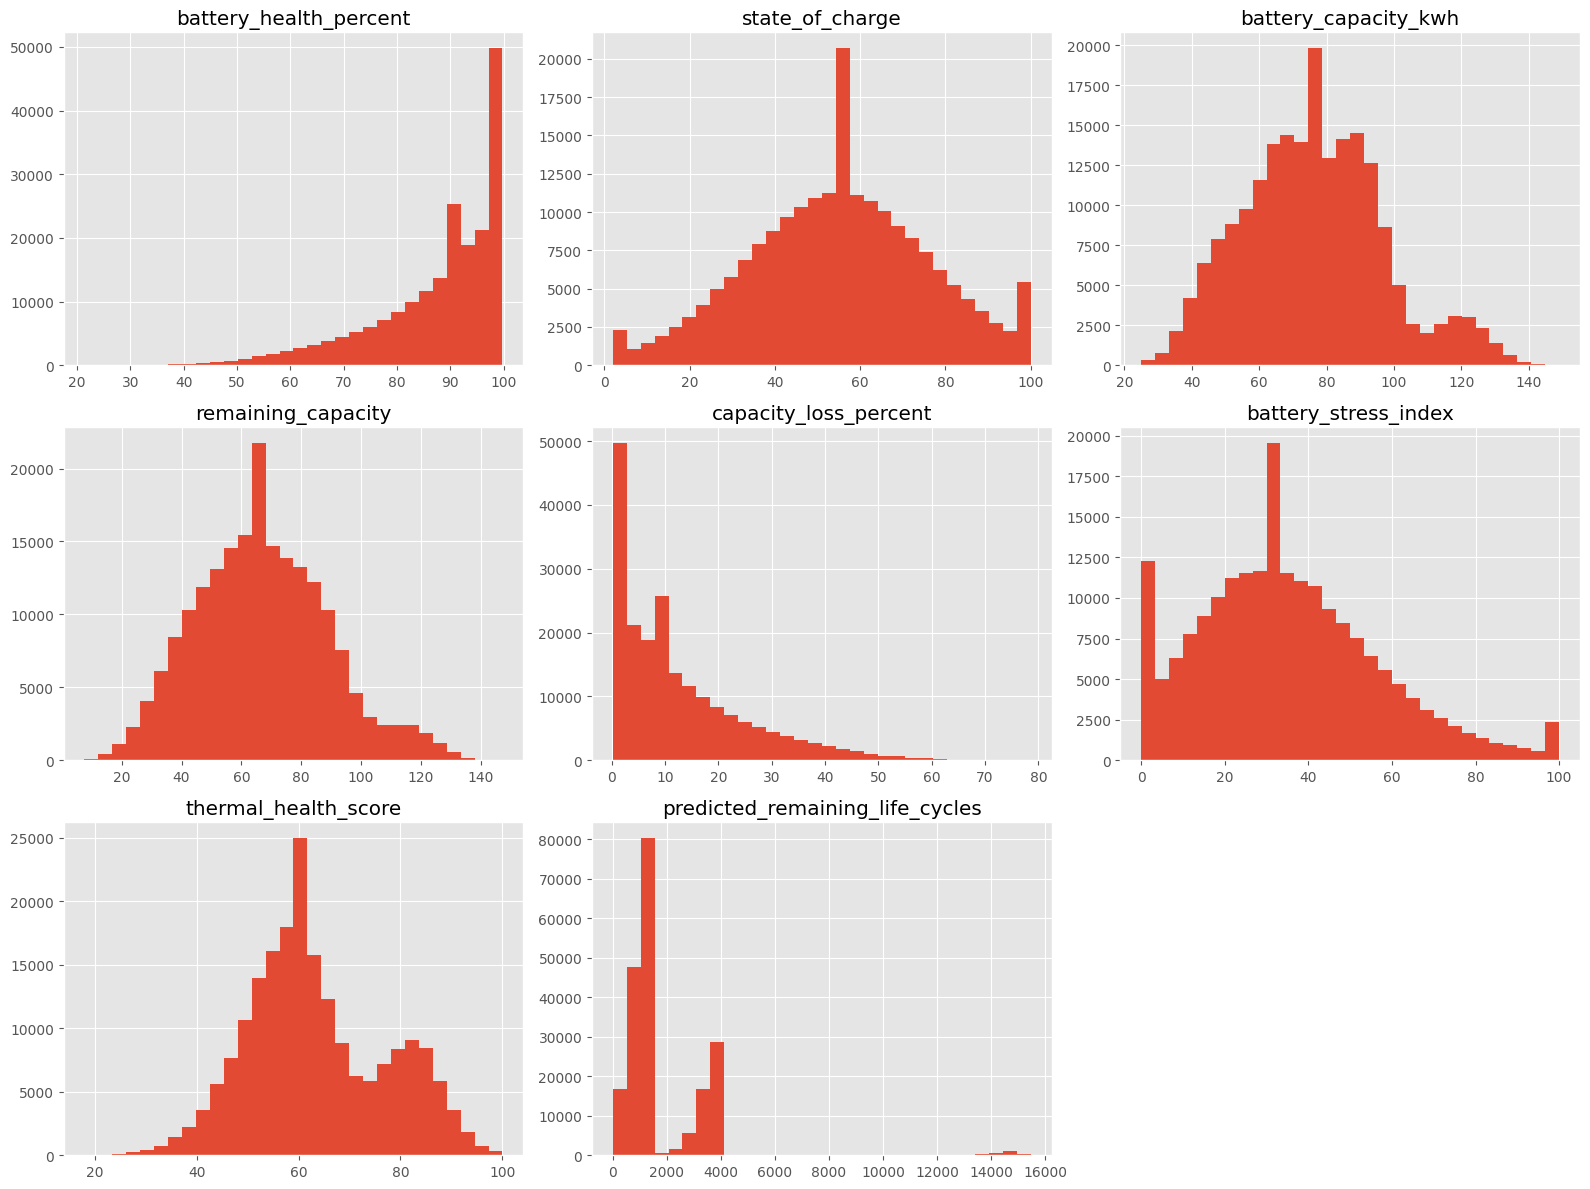

In [77]:
important_features = [
    "battery_health_percent",
    "state_of_charge",
    "battery_capacity_kwh",
    "remaining_capacity",
    "capacity_loss_percent",
    "battery_stress_index",
    "thermal_health_score",
    "predicted_remaining_life_cycles"
]

df[important_features].hist(
    figsize=(16,12),
    bins=30
)

plt.tight_layout()
plt.show()

Step 7 — Boxplots (Outlier Detection)

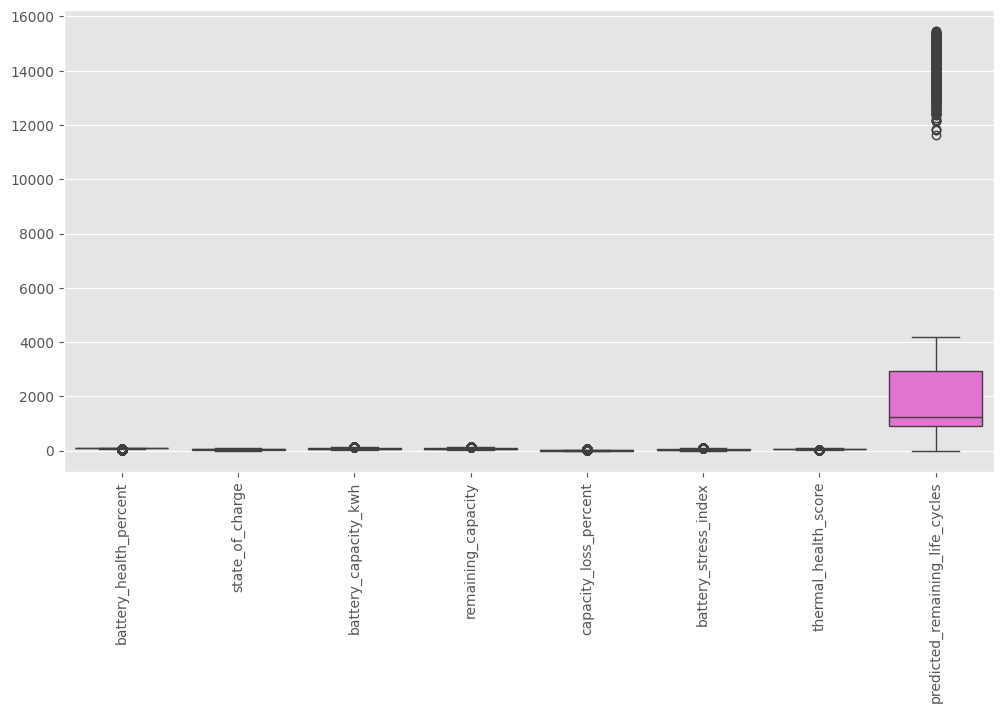

In [78]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[important_features]
)

plt.xticks(rotation=90)

plt.show()

Step 8 — Correlation Matrix

In [79]:
correlation = df.corr(numeric_only=True)

target_corr = (
    correlation["battery_failure"]
    .sort_values(ascending=False)
)

target_corr.head(15)

battery_failure               1.000000
capacity_loss_percent         0.622422
aging_score                   0.585348
cell_voltage_std              0.576512
cycle_count                   0.506092
odometer_km                   0.498706
voltage_imbalance             0.488066
thermal_runaway_risk          0.384101
daily_distance                0.352289
internal_resistance           0.344645
charging_cycles_last_month    0.330564
average_trip_distance         0.305959
battery_stress_index          0.295073
BMS_warning_count             0.277021
fast_charge_ratio             0.276267
Name: battery_failure, dtype: float64

In [80]:
target_corr.tail(15)

average_charging_time             -0.174315
overnight_charging_ratio          -0.182292
discharge_efficiency              -0.203563
predicted_remaining_life_cycles   -0.232660
home_charging_ratio               -0.237141
manufacturing_year                -0.261582
slow_charge_ratio                 -0.273801
cooling_system_health             -0.276825
remaining_capacity                -0.319323
fleet_or_private_Private          -0.329917
thermal_health_score              -0.380715
charging_quality_score            -0.413888
charge_efficiency                 -0.511596
state_of_health                   -0.618403
battery_health_percent            -0.622035
Name: battery_failure, dtype: float64

Step 9 — Heatmap of Top Correlated Features

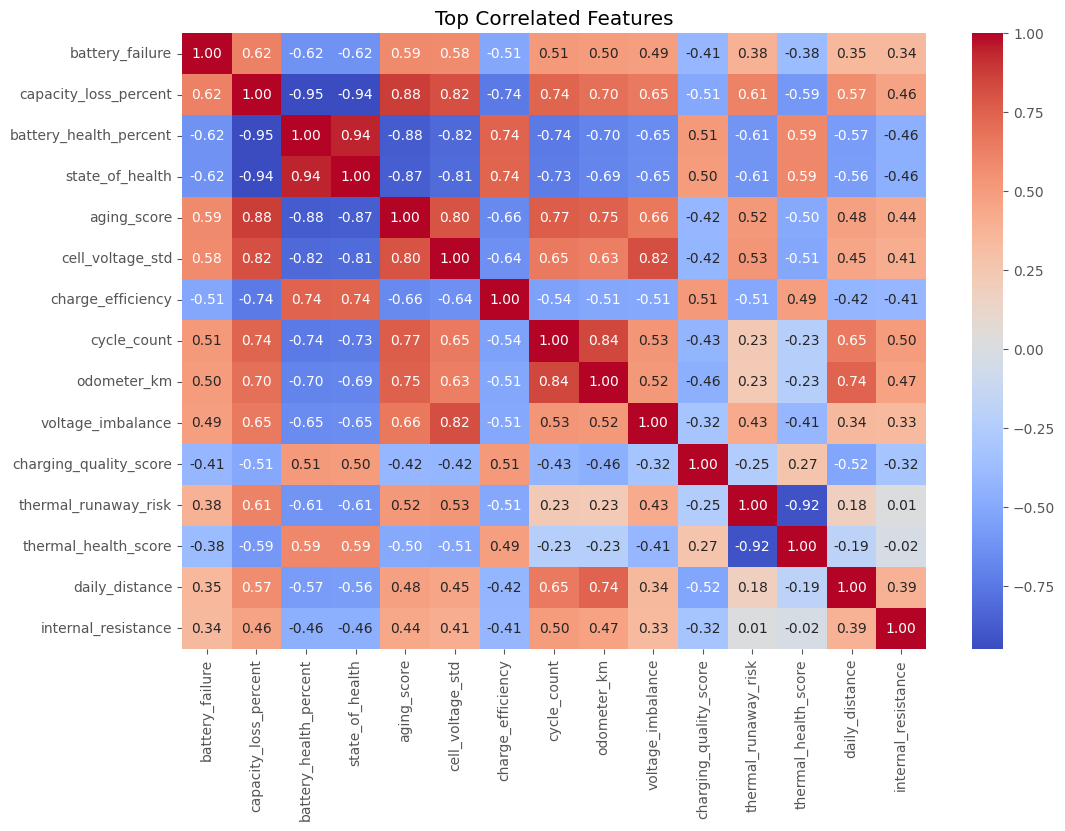

In [81]:
top_features = target_corr.abs().sort_values(
    ascending=False
).head(15).index

plt.figure(figsize=(12,8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Top Correlated Features")

plt.show()

Step 10 — Categorical Feature Distribution

In [82]:
categorical_features = df.select_dtypes(include="object").columns.tolist()


In [83]:
for feature in categorical_features:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=feature,
        order=df[feature].value_counts().index
    )

    plt.xticks(rotation=45)

    plt.title(feature)

    plt.show()

Step 11 — Numerical Features vs Target

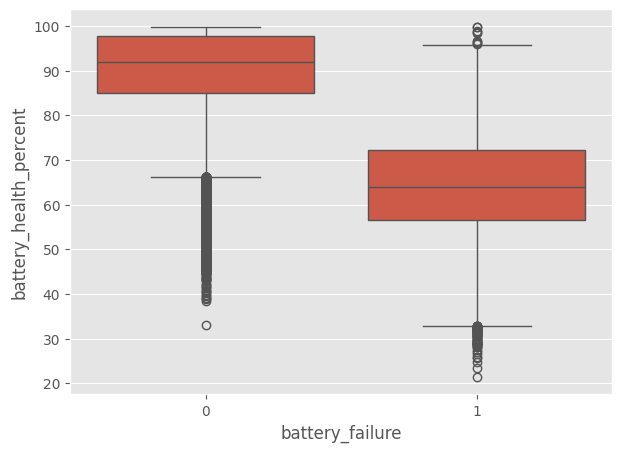

In [85]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="battery_failure",
    y="battery_health_percent",
    data=df
)

plt.show()

Step 12 — Feature Variance

In [89]:
df.var(numeric_only=True).sort_values(
    ascending=False
).head(15)

odometer_km                        7.426381e+09
predicted_remaining_life_cycles    3.230066e+06
altitude                           1.332542e+05
cycle_count                        7.704113e+04
pack_voltage                       2.758736e+04
last_service_days                  1.569453e+04
average_charging_time              1.041316e+04
daily_distance                     1.195018e+03
driving_stress_score               8.607330e+02
aging_score                        7.539600e+02
charging_quality_score             7.461073e+02
remaining_capacity                 4.908486e+02
battery_stress_index               4.575543e+02
battery_capacity_kwh               4.381528e+02
state_of_charge                    4.379502e+02
dtype: float64

## Summary

✔ Verified that the dataset is balanced (or identified any imbalance).

✔ Explored the distributions of key numerical features.

✔ Examined categorical feature frequencies.

✔ Visualized relationships between features and the target.

✔ Detected outliers (Decision Trees can generally handle them).

✔ Identified features most strongly correlated with battery failure.

✔ Compared numerical feature statistics across failure classes.

### Key Insights

- Features such as `battery_health_percent`, `remaining_capacity`, and `battery_stress_index` appear to have strong relationships with battery failure.
- Certain battery chemistries and vehicle types may exhibit different failure patterns.
- The dataset contains meaningful patterns suitable for tree-based classification.

### Next Notebook

**04_Decision_Tree_Model.ipynb**

We'll cover:
- Train-test split
- Decision Tree fundamentals (Entropy, Gini, Information Gain)
- Model training
- Hyperparameter tuning
- Feature importance
- Saving the trained model